# 13. Computational Cost Measuring

Avaliação de **custo computacional** (tempo de execução em segundos) comparando as técnicas de explicabilidade local **LIME Local** e **SHAP Local**.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.helpers import load_pickle
from src.evaluation.computational_cost import measure_execution_time

from src.explainers.shap_explainer import (
    create_explainer as create_shap_explainer,
    explain_instance as explain_shap_instance,
)

from src.explainers.lime_explainer import (
    create_lime_explainer,
    create_predict_fn,
    transform_instance_for_lime,
    explain_instance as explain_lime_instance,
)

c:\Users\anderson\Downloads\GIT\demand-forecast-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load model and data
artifact_dir = Path(
    '../experiments/exp_001_lgbm/artifacts'
)

store_filter = ['CA_1', 'TX_1']
if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'

model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'
model = load_pickle(model_path)

x_train_path = artifact_dir / f'X_train_{store_suffix}.parquet'
X_train = pd.read_parquet(x_train_path)

x_test_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'
X_test = pd.read_parquet(x_test_path)

sample_path = artifact_dir / f'sample_{store_suffix}.parquet'
sample_df = pd.read_parquet(sample_path)


# Config
random_state = 42
num_samples = 5000

categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl


In [4]:
# Config LIME

lime_explainer, X_train_lime, lime_metadata = create_lime_explainer(
    X_train=X_train,
    categorical_cols=categorical_cols,
    random_state=random_state,
)

predict_fn = create_predict_fn(
    model=model,
    metadata=lime_metadata,
)

# Config SHAP

shap_explainer = create_shap_explainer(
    model
)

In [5]:
results = []

instance_ids = sample_df['instance_id'].tolist()


for _, sample_row in sample_df.iterrows():

    instance_id = sample_row['instance_id']

    prediction_quality = (
        sample_row['prediction_quality']
    )

    instance = X_test.iloc[
        [instance_id]
    ].copy()


    # =========================
    # SHAP
    # =========================

    _, shap_elapsed = measure_execution_time(
        func=explain_shap_instance,
        explainer=shap_explainer,
        instance=instance,
        instance_id=instance_id,
    )

    results.append({
        'instance_id': instance_id,
        'prediction_quality': prediction_quality,
        'method': 'SHAP',
        'elapsed_seconds': shap_elapsed,
    })


    # =========================
    # LIME
    # =========================

    lime_instance = instance.iloc[0]

    instance_lime = (
        transform_instance_for_lime(
            instance=lime_instance,
            metadata=lime_metadata,
        )
    )

    _, lime_elapsed = measure_execution_time(
        func=explain_lime_instance,
        explainer=lime_explainer,
        predict_fn=predict_fn,
        instance=lime_instance,
        instance_lime=instance_lime,
        instance_id=instance_id,
        num_samples=num_samples,
    )

    results.append({
        'instance_id': instance_id,
        'prediction_quality': prediction_quality,
        'method': 'LIME',
        'elapsed_seconds': lime_elapsed,
    })

In [6]:
computational_cost_results = pd.DataFrame(
    results
)

computational_cost_results.head()

,instance_id,prediction_quality,method,elapsed_seconds
0,25407,good,SHAP,0.011522
1,25407,good,LIME,0.040149
2,35336,good,SHAP,0.011189
3,35336,good,LIME,0.037144
4,117457,good,SHAP,0.010265


In [7]:
computational_cost_summary = (
    computational_cost_results
    .groupby("method")["elapsed_seconds"]
    .agg(
        mean="mean",
        std="std",
        median="median",
    )
    .reset_index()
)

computational_cost_summary

,method,mean,std,median
0,LIME,0.039545,0.007918,0.037466
1,SHAP,0.011288,0.000978,0.011015


In [8]:
computational_cost_by_instance = (
    computational_cost_results
    .sort_values(
        [
            "instance_id",
            "method",
        ]
    )
    .reset_index(drop=True)
)

computational_cost_by_instance.head()

,instance_id,prediction_quality,method,elapsed_seconds
0,1919,good,LIME,0.035735
1,1919,good,SHAP,0.011265
2,2530,good,LIME,0.038221
3,2530,good,SHAP,0.010792
4,3326,bad,LIME,0.036044


In [9]:
mean_cost = (
    computational_cost_results
    .groupby("method")["elapsed_seconds"]
    .mean()
)

lime_shap_ratio = (
    mean_cost["LIME"]
    / mean_cost["SHAP"]
)

print(
    f"LIME/SHAP mean execution time ratio: "
    f"{lime_shap_ratio:.2f}x"
)

LIME/SHAP mean execution time ratio: 3.50x


In [10]:
computational_cost_results.to_parquet(
    artifact_dir
    / f"computational_cost_results_{store_suffix}.parquet",
    index=False,
)

computational_cost_summary.to_parquet(
    artifact_dir
    / f"computational_cost_summary_{store_suffix}.parquet",
    index=False,
)

# Analysis

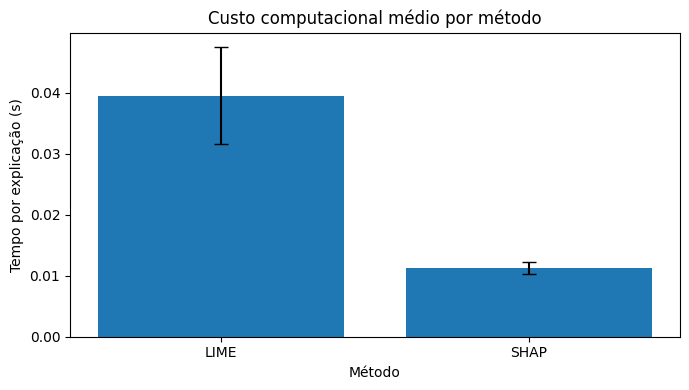

In [11]:
import matplotlib.pyplot as plt

summary = (
    computational_cost_results
    .groupby('method')['elapsed_seconds']
    .agg(['mean', 'std'])
    .reset_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    summary['method'],
    summary['mean'],
    yerr=summary['std'],
    capsize=5
)

plt.ylabel('Tempo por explicação (s)')
plt.xlabel('Método')
plt.title('Custo computacional médio por método')

plt.tight_layout()
plt.show()

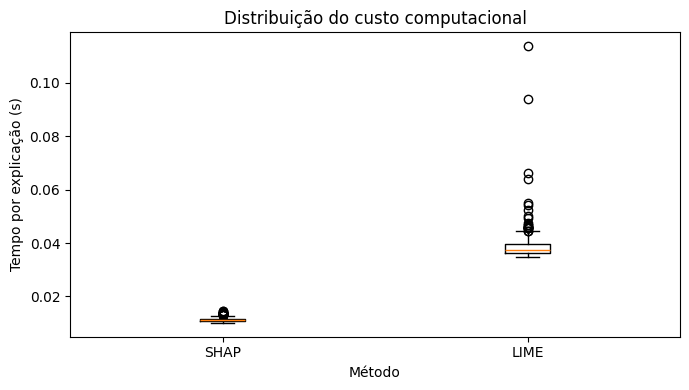

In [12]:

methods = ['SHAP', 'LIME']

data = [
    computational_cost_results.loc[
        computational_cost_results['method'] == method,
        'elapsed_seconds'
    ]
    for method in methods
]

plt.figure(figsize=(7, 4))

plt.boxplot(
    data,
    tick_labels=methods
)

plt.ylabel('Tempo por explicação (s)')
plt.xlabel('Método')
plt.title('Distribuição do custo computacional')

plt.tight_layout()
plt.show()

In [13]:
cost_by_quality = (
    computational_cost_results
    .groupby(['method', 'prediction_quality'])['elapsed_seconds']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

cost_by_quality

,method,prediction_quality,mean,median,std
0,LIME,bad,0.039098,0.037575,0.004676
1,LIME,good,0.039993,0.037444,0.010186
2,SHAP,bad,0.011336,0.011029,0.000970
3,SHAP,good,0.011241,0.010971,0.000988


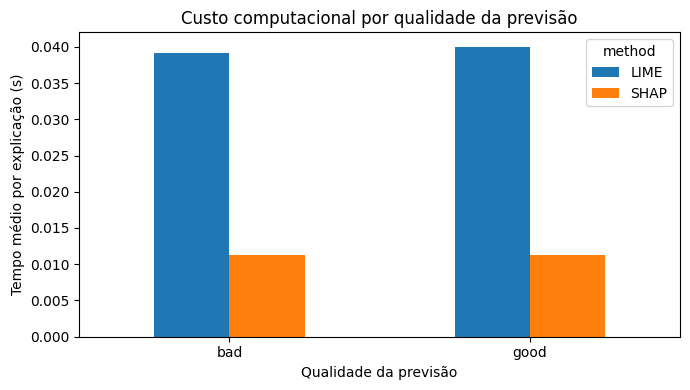

In [14]:

pivot = (
    cost_by_quality
    .pivot(
        index='prediction_quality',
        columns='method',
        values='mean'
    )
)

pivot.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.ylabel('Tempo médio por explicação (s)')
plt.xlabel('Qualidade da previsão')
plt.title('Custo computacional por qualidade da previsão')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
mean_cost = (
    computational_cost_results
    .groupby('method')['elapsed_seconds']
    .mean()
)

shap_mean = mean_cost['SHAP']
lime_mean = mean_cost['LIME']

speed_ratio = lime_mean / shap_mean

reduction_pct = (
    (lime_mean - shap_mean)
    / lime_mean
) * 100

print(f'SHAP médio: {shap_mean:.5f} s')
print(f'LIME médio: {lime_mean:.5f} s')
print(f'LIME / SHAP: {speed_ratio:.2f}x')
print(f'Redução do SHAP: {reduction_pct:.1f}%')

SHAP médio: 0.01129 s
LIME médio: 0.03955 s
LIME / SHAP: 3.50x
Redução do SHAP: 71.5%


In [20]:
cost_paired = (
    computational_cost_results
    .pivot(
        index='instance_id',
        columns='method',
        values='elapsed_seconds'
    )
    .dropna()
    .reset_index()
)

cost_paired['difference'] = (
    cost_paired['LIME'] - cost_paired['SHAP']
)

cost_paired['ratio'] = (
    cost_paired['LIME'] / cost_paired['SHAP']
)

cost_paired['mean_difference'] = (cost_paired['difference'] > 0).mean()

cost_paired[['difference', 'ratio']].describe()

method,difference,ratio
count,200.000000,200.000000
mean,0.028257,3.505197
std,0.007568,0.606226
min,0.022341,2.569097
25%,0.025343,3.293995
50%,0.026393,3.419382
75%,0.028627,3.572143
max,0.102411,10.016843


In [21]:
from scipy.stats import wilcoxon

statistic, p_value = wilcoxon(
    cost_paired['LIME'],
    cost_paired['SHAP']
)

print(f'Estatística: {statistic:.4f}')
print(f'p-value: {p_value:.6f}')

Estatística: 0.0000
p-value: 0.000000


In [22]:
comparison_summary = {
    'n_instances': len(cost_paired),
    'shap_mean': cost_paired['SHAP'].mean(),
    'lime_mean': cost_paired['LIME'].mean(),
    'mean_difference': cost_paired['difference'].mean(),
    'median_difference': cost_paired['difference'].median(),
    'mean_ratio': cost_paired['ratio'].mean(),
    'median_ratio': cost_paired['ratio'].median(),
    'lime_slower_pct': (cost_paired['difference'] > 0).mean() * 100,
    'wilcoxon_statistic': statistic,
    'p_value': p_value,
}

comparison_summary

{'n_instances': 200,
 'shap_mean': np.float64(0.011288345999992089),
 'lime_mean': np.float64(0.0395454429999927),
 'mean_difference': np.float64(0.028257097000000612),
 'median_difference': np.float64(0.026393449999886798),
 'mean_ratio': np.float64(3.5051973955763587),
 'median_ratio': np.float64(3.4193823653341404),
 'lime_slower_pct': np.float64(100.0),
 'wilcoxon_statistic': np.float64(0.0),
 'p_value': np.float64(1.4361464127613523e-34)}

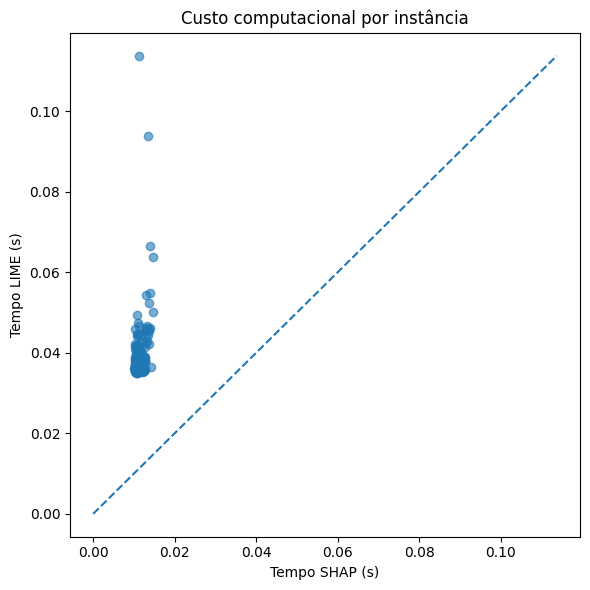

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    cost_paired['SHAP'],
    cost_paired['LIME'],
    alpha=0.6
)

max_time = max(
    cost_paired['SHAP'].max(),
    cost_paired['LIME'].max()
)

plt.plot(
    [0, max_time],
    [0, max_time],
    '--'
)

plt.xlabel('Tempo SHAP (s)')
plt.ylabel('Tempo LIME (s)')
plt.title('Custo computacional por instância')

plt.tight_layout()
plt.show()